# Does conditioning help? — RMSD vs number of hotspots on a site

Each `rfd_denovo30` design was generated by RFdiffusion under a named **conditioning** = a set of
`ppi.hotspot_res` residues on the MHC groove (chain A) and TCR (chains D/E) that RFD1 is told to keep
the new peptide in contact with. The conditionings form a deliberate ladder, from 1 hotspot (`tcr1`)
up to 10 (`L5_max`):

| cond | hotspots (6AM5, withTCR) | n |
|---|---|---|
| `tcr1` | E97 | 1 |
| `tcr2` | E97,D30 | 2 |
| `L1_nterm` | A159,A66,A70 | 3 |
| `L2_nterm_t1` | +E97 | 4 |
| `L3_nterm_t2` | +D30 | 5 |
| `mhc` | A9,A63,A66,A77,A80,A116,A143 | 7 |
| `L4_expanded` | A159,A66,A70,A9,A77,A80,E97,D30 | 8 |
| `mhc_tcr2` | mhc + E97,D30 | 9 |
| `L5_max` | A159,A66,A70,A9,A77,A80,A116,A143,E97,D30 | 10 |

*(noTCR cells drop the TCR hotspots E/D.)* We ask: **does adding hotspots lower the peptide Cα-RMSD to
the native register — and specifically, does putting more conditioning on the *site that touches a
given peptide residue* pull *that residue* closer?**

In [1]:
import os, sys, re, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from Bio.PDB import PDBParser
import score_denovo_designs as S
try:
    from scipy.stats import spearmanr, pearsonr; HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
ROOT = S.ROOT; CUT = 5.0        # heavy-atom contact cutoff (A)
print("scipy:", HAVE_SCIPY)

scipy: True


## 1 · Parse the conditioning spec — name + hotspot set per design

`jobs/rfd_denovo30_spec.tsv` maps each cell `{pid}_{context}_{cond}` to its exact hotspot list. We key
it by (pid, context, cond) so the noTCR/withTCR difference (TCR hotspots stripped) is respected.

In [2]:
SPEC = f"{ROOT}/jobs/rfd_denovo30_spec.tsv"
cond_hot = {}                    # (pid, context, cond) -> [(chain, resnum), ...]
for line in open(SPEC):
    parts = line.rstrip("\n").split("\t")
    if len(parts) < 6: continue
    cell, pid, ctx, cond, contig, hot = parts[:6]
    hs = []
    for tok in hot.replace(" ", "").split(","):
        m = re.match(r"([A-Za-z])(\d+)$", tok)
        if m: hs.append((m.group(1), int(m.group(2))))
    cond_hot[(pid, ctx, cond)] = hs
spec_df = pd.DataFrame([dict(pid=k[0], context=k[1], cond=k[2],
                             n_hot=len(v), hotspots=",".join(f"{c}{n}" for c, n in v))
                        for k, v in cond_hot.items()])
spec_df.sort_values(["pid", "context", "n_hot"]).reset_index(drop=True)

,pid,context,cond,n_hot,hotspots
0,6AM5,noTCR,tcr1,0,
1,6AM5,noTCR,tcr2,0,
2,6AM5,noTCR,L1_nterm,3,"A159,A66,A70"
3,6AM5,noTCR,L2_nterm_t1,3,"A159,A66,A70"
4,6AM5,noTCR,L3_nterm_t2,3,"A159,A66,A70"
5,6AM5,noTCR,L4_expanded,6,"A159,A66,A70,A9,A77,A80"
6,6AM5,noTCR,mhc,7,"A9,A63,A66,A77,A80,A116,A143"
7,6AM5,noTCR,mhc_tcr1,7,"A9,A63,A66,A77,A80,A116,A143"
8,6AM5,noTCR,mhc_tcr2,7,"A9,A63,A66,A77,A80,A116,A143"
9,6AM5,noTCR,L5_max,8,"A159,A66,A70,A9,A77,A80,A116,A143"


## 2 · Native contact map — which SITE touches which peptide residue

For each hotspot site we take its heavy atoms in the native crystal (`inputs/focus_6am/{pid}_trim.pdb`,
the exact structure whose numbering the hotspots reference) and measure the minimum distance to every
peptide residue p1..p10. A site **interacts** with a peptide position if that min distance ≤ 5 Å.
This is the "**what are the sites that interact with that residue**" answer, and it's what lets us count,
per peptide position, how many of a design's conditioning hotspots are aimed at it.

In [3]:
def heavy(res): return np.array([a.coord for a in res if a.element != "H"])
contact = {}                     # pid -> {(chain,resnum): {pos: min_dist}}
site_touches = {}                # pid -> {(chain,resnum): [positions <= CUT]}
p = PDBParser(QUIET=True)
for pid in ("6AM5", "6AMU"):
    mdl = p.get_structure(pid, f"{ROOT}/inputs/focus_6am/{pid}_trim.pdb")[0]
    pep = {r.id[1]: heavy(r) for r in mdl["C"] if r.id[0] == " "}
    contact[pid] = {}; site_touches[pid] = {}
    allsites = sorted({s for k, v in cond_hot.items() if k[0] == pid for s in v})
    for ch, n in allsites:
        if ch not in mdl: contact[pid][(ch, n)] = {}; site_touches[pid][(ch, n)] = []; continue
        rr = [r for r in mdl[ch] if r.id[0] == " " and r.id[1] == n]
        if not rr: contact[pid][(ch, n)] = {}; site_touches[pid][(ch, n)] = []; continue
        hv = heavy(rr[0])
        d = {pp: float(np.linalg.norm(hv[:, None] - pc[None], axis=2).min()) for pp, pc in pep.items()}
        contact[pid][(ch, n)] = d
        site_touches[pid][(ch, n)] = sorted([pp for pp, dv in d.items() if dv <= CUT])

# tidy "site -> residues it interacts with" table (6AM5)
rowz = []
for (ch, n), d in contact["6AM5"].items():
    near = min(d, key=d.get) if d else None
    rowz.append(dict(site=f"{ch}{n}", region=("TCR" if ch in "DE" else "MHC"),
                     nearest=f"p{near}" if near else "-",
                     nearest_A=round(d[near], 1) if near else None,
                     touches=" ".join(f"p{x}" for x in site_touches["6AM5"][(ch, n)])))
pd.DataFrame(rowz).sort_values("nearest_A")

,site,region,nearest,nearest_A,touches
8,A159,MHC,p1,2.6,p1 p2 p3
9,D30,TCR,p2,2.7,p1 p2 p3 p4 p5
7,A143,MHC,p10,2.8,p10
4,A77,MHC,p10,2.8,p8 p9 p10
1,A63,MHC,p2,3.0,p1 p2
2,A66,MHC,p2,3.0,p1 p2 p3 p4
3,A70,MHC,p3,3.2,p2 p3 p7
10,E97,TCR,p4,3.3,p3 p4 p5 p7
5,A80,MHC,p10,3.6,p10
6,A116,MHC,p10,3.6,p10


### Contact heatmap — hotspot site × peptide position (native, 6AM5)

Darker = closer. The green boxes mark the ≤5 Å contacts we count as "this site conditions this residue".

saved denovo_site_contact_map.png


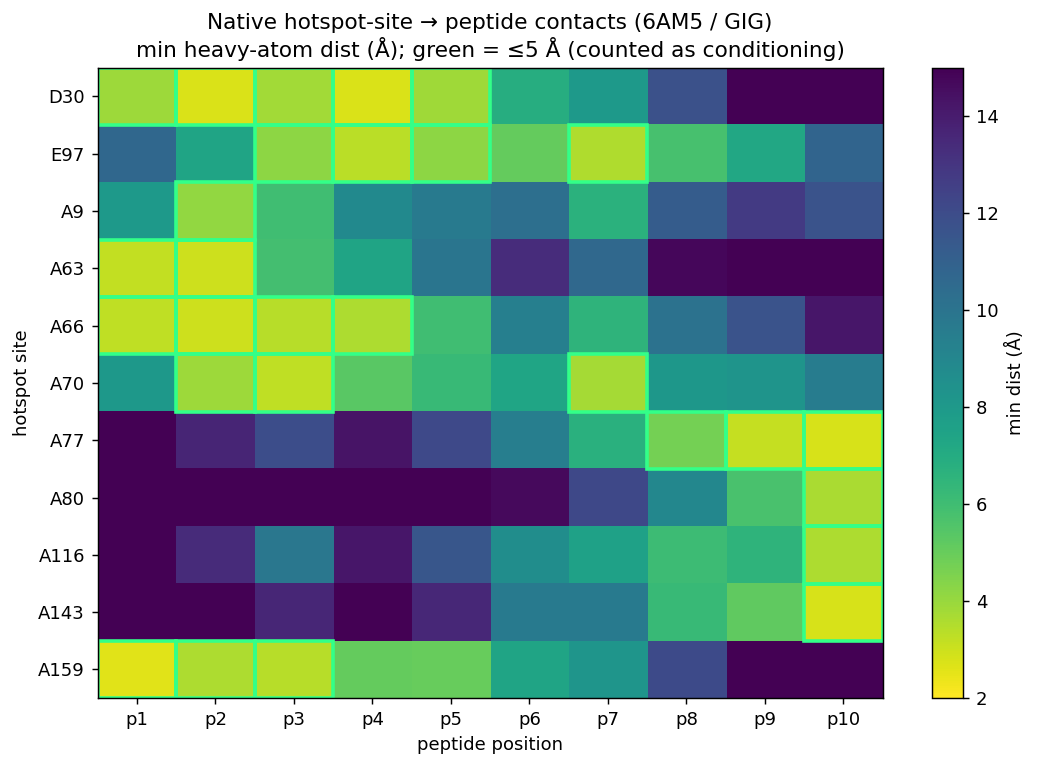

In [4]:
sites = [s for s in sorted(contact["6AM5"], key=lambda k: (k[0] not in "DE", k[0], k[1]))]
pos = list(range(1, 11))
M = np.array([[contact["6AM5"][s].get(pp, np.nan) for pp in pos] for s in sites])
fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(M, cmap="viridis_r", vmin=2, vmax=15, aspect="auto")
ax.set_xticks(range(10)); ax.set_xticklabels([f"p{i}" for i in pos])
ax.set_yticks(range(len(sites))); ax.set_yticklabels([f"{c}{n}" for c, n in sites])
for i, s in enumerate(sites):
    for j, pp in enumerate(pos):
        if not np.isnan(M[i, j]) and M[i, j] <= CUT:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="#33ff88", lw=2))
ax.set_xlabel("peptide position"); ax.set_ylabel("hotspot site")
ax.set_title("Native hotspot-site → peptide contacts (6AM5 / GIG)\nmin heavy-atom dist (Å); green = ≤5 Å (counted as conditioning)")
fig.colorbar(im, label="min dist (Å)"); plt.tight_layout()
plt.savefig(f"{ROOT}/figures/denovo_site_contact_map.png", dpi=150); print("saved denovo_site_contact_map.png"); plt.show()

## 3 · Score all rfd_denovo30 designs & attach conditioning counts

Per design we record the cognate-register per-position deviation (`S.score_perres`), the total hotspot
count `n_hot`, and — for every peptide position — `n_cond_at_pos` = how many of *that design's* hotspots
touch *that* position in the native crystal.

In [5]:
files = S.gather([f"{ROOT}/outputs/rfd_denovo30/pdb"])
rows, pr = [], []
for f in files:
    sc = S.score_perres(f)
    if sc is None or sc["devGIG"] is None: continue
    meta = S.parse_meta(f)
    key = (meta["pid"], meta["context"], meta["cond"])
    hs = cond_hot.get(key)
    if hs is None: continue                                  # not a spec cell
    cog = sc["devGIG"] if meta["pid"] == "6AM5" else sc["devDRG"]
    rms = float(np.sqrt((cog ** 2).mean()))
    rows.append(dict(**meta, n_hot=len(hs), to_cognate=rms, file=os.path.basename(f)))
    for p_ in range(1, 11):
        ncond = sum(1 for s in hs if p_ in site_touches[meta["pid"]].get(s, []))
        pr.append(dict(pid=meta["pid"], context=meta["context"], cond=meta["cond"], n_hot=len(hs),
                       pos=p_, dev=cog[p_ - 1], n_cond_at_pos=ncond))
D = pd.DataFrame(rows); PR = pd.DataFrame(pr)
print(f"scored {len(D)} denovo30 designs across {D.cond.nunique()} conditionings; "
      f"{len(PR)} (design x position) rows")
D.groupby(["cond"]).agg(n=("file", "size"), n_hot=("n_hot", "first"),
                        cog_med=("to_cognate", "median"), cog_best=("to_cognate", "min")).round(2).sort_values("n_hot")

scored 214 denovo30 designs across 10 conditionings; 2140 (design x position) rows


,n,n_hot,cog_med,cog_best
cond,,,,
tcr2,24,0,12.60,3.12
tcr1,24,0,11.88,2.90
L1_nterm,20,3,12.70,3.91
L2_nterm_t1,20,3,12.89,3.45
L3_nterm_t2,20,3,12.70,3.63
L4_expanded,20,6,10.52,3.44
mhc,24,7,12.70,2.72
mhc_tcr1,22,7,12.52,3.40
mhc_tcr2,20,7,12.96,3.58


## A · Aggregate correlation — #hotspots in a cell vs cognate RMSD

Each point is one (pid, context, cond) cell: x = number of conditioning hotspots, y = median cognate
Cα-RMSD over that cell's designs. If conditioning helps, more hotspots → lower RMSD (negative slope).

saved denovo_cond_rmsd_aggregate.png


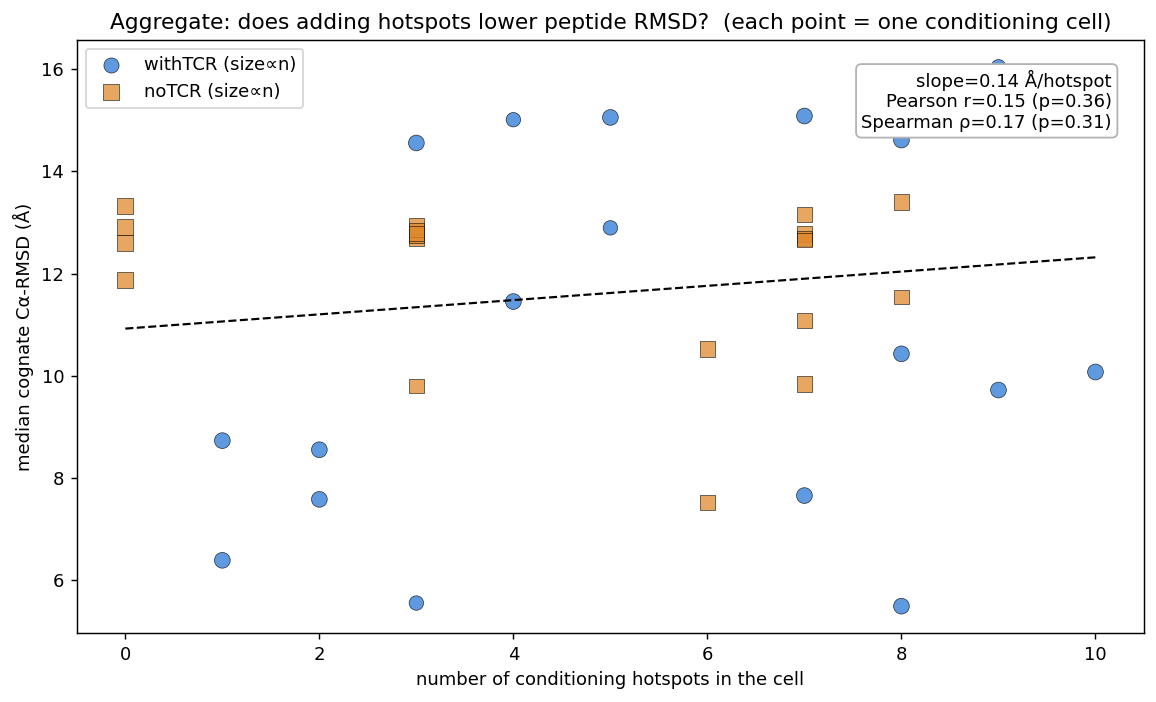

In [6]:
cell = D.groupby(["pid", "context", "cond"]).agg(
    n_hot=("n_hot", "first"), rmsd_med=("to_cognate", "median"),
    rmsd_lo=("to_cognate", "min"), n=("file", "size")).reset_index()
fig, ax = plt.subplots(figsize=(9, 5.5))
for ctx, mk, cl in [("withTCR", "o", "#2a78d6"), ("noTCR", "s", "#e08a2e")]:
    sub = cell[cell.context == ctx]
    ax.scatter(sub.n_hot, sub.rmsd_med, s=40 + 6 * sub.n, marker=mk, color=cl, alpha=.75,
               edgecolor="k", lw=.4, label=f"{ctx} (size∝n)")
# least-squares line over all cells
x, y = cell.n_hot.values.astype(float), cell.rmsd_med.values
b1, b0 = np.polyfit(x, y, 1); xs = np.array([x.min(), x.max()])
ax.plot(xs, b0 + b1 * xs, "k--", lw=1.2)
txt = f"slope={b1:.2f} Å/hotspot"
if HAVE_SCIPY:
    rp, pp = pearsonr(x, y); rs, ps = spearmanr(x, y)
    txt += f"\nPearson r={rp:.2f} (p={pp:.2g})\nSpearman ρ={rs:.2f} (p={ps:.2g})"
ax.text(.97, .95, txt, transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", fc="w", ec="0.7"))
ax.set_xlabel("number of conditioning hotspots in the cell")
ax.set_ylabel("median cognate Cα-RMSD (Å)")
ax.set_title("Aggregate: does adding hotspots lower peptide RMSD?  (each point = one conditioning cell)")
ax.legend(); plt.tight_layout()
plt.savefig(f"{ROOT}/figures/denovo_cond_rmsd_aggregate.png", dpi=150); print("saved denovo_cond_rmsd_aggregate.png"); plt.show()

## B · Per-residue correlation — conditioning ON a site vs RMSD AT that residue

This is the direct test. Pool all (design × peptide-position) observations; the predictor is
`n_cond_at_pos` (how many of that design's hotspots touch that position), the response is that
position's Cα deviation. If steering a residue with more nearby hotspots pulls it toward native, the
deviation should fall as `n_cond_at_pos` rises.

saved denovo_cond_rmsd_perresidue.png


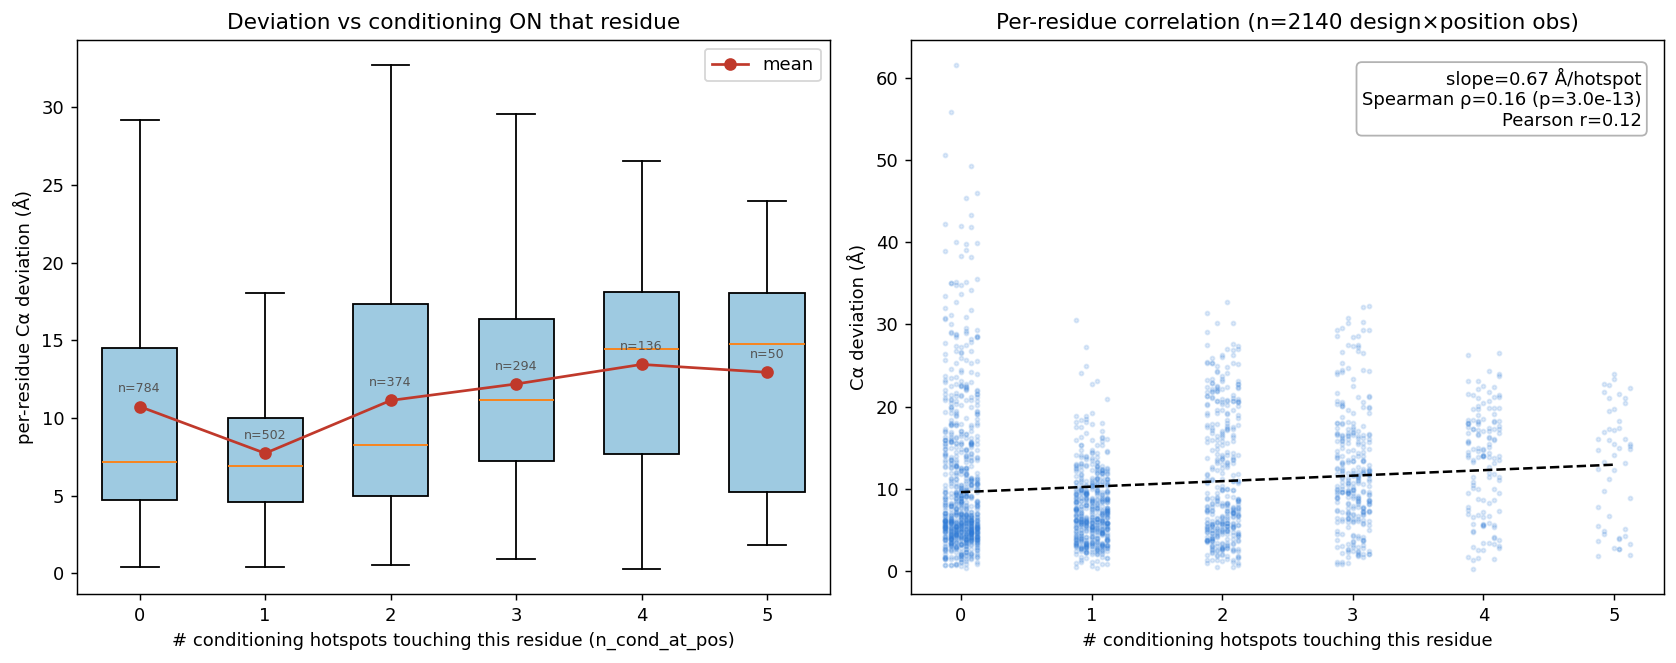

In [7]:
grp = PR.groupby("n_cond_at_pos")["dev"]
levels = sorted(PR.n_cond_at_pos.unique())
means = grp.mean().reindex(levels); sds = grp.std().reindex(levels); ns = grp.size().reindex(levels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
# left: box per conditioning-count level
data = [PR[PR.n_cond_at_pos == k]["dev"].values for k in levels]
bp = ax1.boxplot(data, positions=levels, widths=.6, showfliers=False, patch_artist=True)
for patch in bp["boxes"]: patch.set_facecolor("#9ecae1")
ax1.plot(levels, means.values, "-o", color="#c0392b", lw=1.5, label="mean")
for k, m_, n_ in zip(levels, means.values, ns.values):
    ax1.annotate(f"n={int(n_)}", (k, m_), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=7, color="#555")
ax1.set_xlabel("# conditioning hotspots touching this residue (n_cond_at_pos)")
ax1.set_ylabel("per-residue Cα deviation (Å)")
ax1.set_title("Deviation vs conditioning ON that residue"); ax1.legend()
# right: correlation scatter (jittered) + line
xj = PR.n_cond_at_pos + np.linspace(-.15, .15, len(PR)) if False else \
     PR.n_cond_at_pos + (np.arange(len(PR)) % 7 - 3) * .04
ax2.scatter(xj, PR.dev, s=5, alpha=.15, color="#2a78d6")
b1, b0 = np.polyfit(PR.n_cond_at_pos, PR.dev, 1); xs = np.array([levels[0], levels[-1]])
ax2.plot(xs, b0 + b1 * xs, "k--", lw=1.4)
txt = f"slope={b1:.2f} Å/hotspot"
if HAVE_SCIPY:
    rs, ps = spearmanr(PR.n_cond_at_pos, PR.dev); rp, pp = pearsonr(PR.n_cond_at_pos, PR.dev)
    txt += f"\nSpearman ρ={rs:.2f} (p={ps:.1e})\nPearson r={rp:.2f}"
ax2.text(.97, .95, txt, transform=ax2.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round", fc="w", ec="0.7"))
ax2.set_xlabel("# conditioning hotspots touching this residue"); ax2.set_ylabel("Cα deviation (Å)")
ax2.set_title(f"Per-residue correlation (n={len(PR)} design×position obs)")
plt.tight_layout(); plt.savefig(f"{ROOT}/figures/denovo_cond_rmsd_perresidue.png", dpi=150)
print("saved denovo_cond_rmsd_perresidue.png"); plt.show()

### Read-out

- **Panel A** asks whether *piling on more hotspots anywhere* lowers the whole-peptide RMSD.
- **Panel B** is the sharper question the request poses: for a *given peptide residue*, does having
  more conditioning hotspots that actually *touch* it pull that residue toward the native register?

The slope / Spearman ρ printed on each figure quantify the effect (negative ⇒ conditioning lowers
RMSD). Given the campaign's finding that RFdiffusion de-novo backbones sit far off-register regardless
of conditioning ([[rfdiff-partial-diffusion-freezes-peptide]], [[nomhc-recovery-tracks-backbone]]),
expect these correlations to be **weak** — the notebook makes that quantitative rather than assumed.